In [38]:
import os
import cv2
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from skimage import feature
from xgboost import XGBClassifier
from google.colab import drive, files
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, VotingClassifier

drive.mount('/content/drive')

imagesFolderPath = '/content/drive/MyDrive/data'
labelsPath = '/content/drive/MyDrive/label.csv'

labelsCSV = pd.read_csv(labelsPath)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
print(labelsCSV.head())

      filename         label
0  Image_1.jpg       sitting
1  Image_2.jpg  using_laptop
2  Image_3.jpg       hugging
3  Image_4.jpg      sleeping
4  Image_5.jpg  using_laptop


#Part A

Number of images per class:
label
sitting               840
using_laptop          840
hugging               840
sleeping              840
drinking              840
clapping              840
dancing               840
cycling               840
calling               840
laughing              840
eating                840
fighting              840
listening_to_music    840
running               840
texting               840
Name: count, dtype: int64



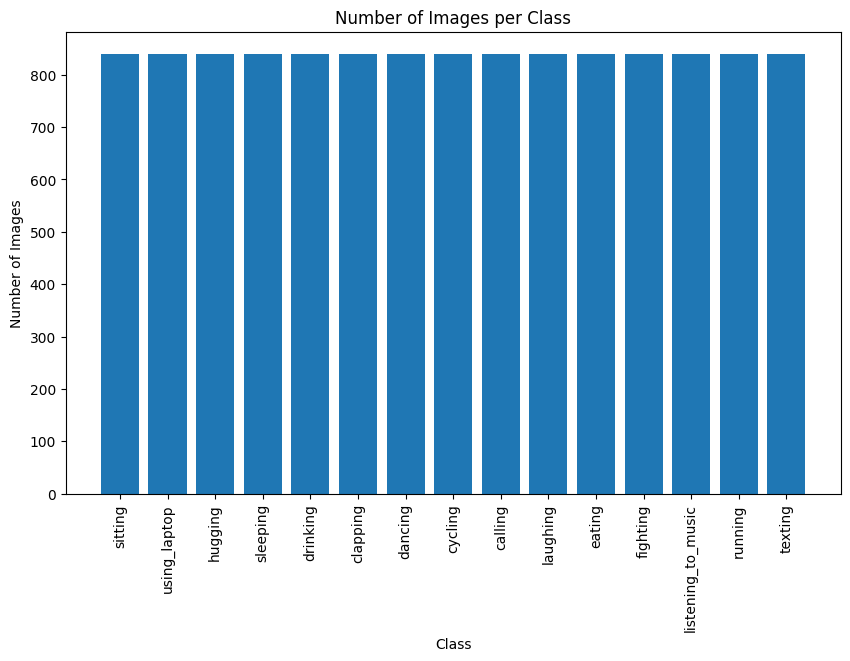

In [40]:
classDistribution = labelsCSV['label'].value_counts()
print("Number of images per class:\n" + str(classDistribution))

print()
plt.figure(figsize = (10, 6))
plt.bar(classDistribution.index, classDistribution.values)
plt.title('Number of Images per Class')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation = 90)

plt.show()

Min Width:  84
Max Width:  478
Mean Width:  260.38103174603174
Std Width:  39.91769674243761

Min Height:  84
Max Height:  318
Mean Height:  196.57357142857143
Std Height:  35.28000220378205



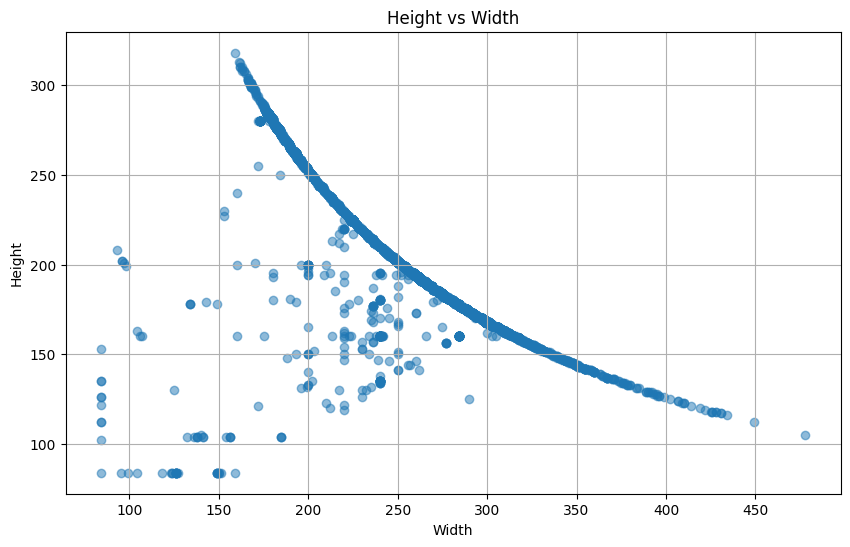

In [57]:
imageSizes = []
count = 0

for imgName in labelsCSV['filename']:
    # print(count)
    imgPath = imagesFolderPath + '/' + imgName
    img = Image.open(imgPath)
    imageSizes.append(img.size)
    count += 1

imageSizes = pd.DataFrame(imageSizes, columns = ['width', 'height'])

widths = imageSizes['width']
heights = imageSizes['height']

minWidth = np.min(widths)
maxWidth = np.max(widths)
meanWidth = np.mean(widths)
stdWidth = np.std(widths)
countWidth = len(widths)

minHeight = np.min(heights)
maxHeight = np.max(heights)
meanHeight = np.mean(heights)
stdHeight = np.std(heights)
countHeight = len(heights)

# print()
print("Min Width: ", minWidth)
print("Max Width: ", maxWidth)
print("Mean Width: ", meanWidth)
print("Std Width: ", stdWidth)

print()
print("Min Height: ", minHeight)
print("Max Height: ", maxHeight)
print("Mean Height: ", meanHeight)
print("Std Height: ", stdHeight)

print()
plt.figure(figsize = (10, 6))
plt.scatter(widths, heights, alpha = 0.5)
plt.title('Height vs Width')
plt.xlabel('Width')
plt.ylabel('Height')
plt.grid()
plt.show()

Sample Images from each Class:



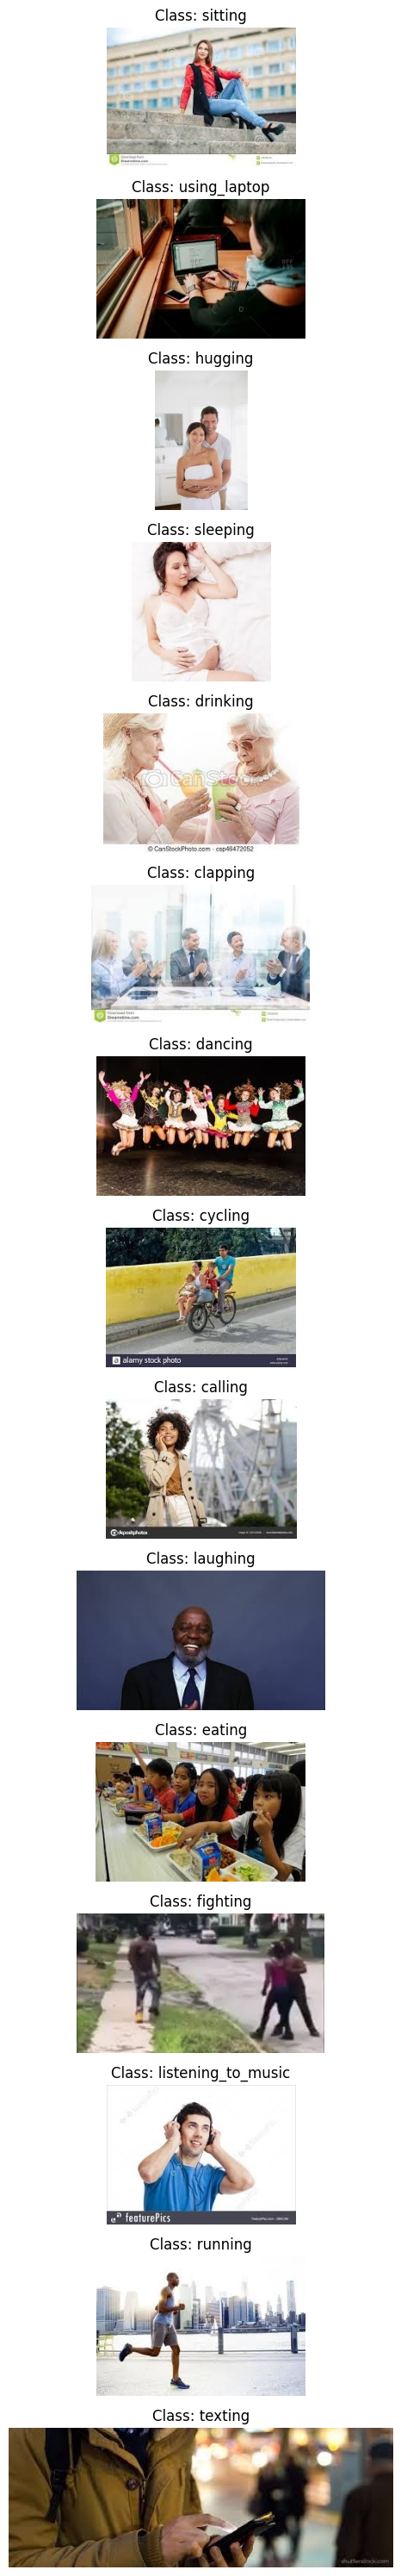

In [45]:
classes = labelsCSV['label'].unique()
n = len(classes)

plt.figure(figsize = (15, n * 2))

print("Sample Images from each Class:\n")

for i in range(n):
    classLabel = classes[i]
    classSamples = labelsCSV[labelsCSV['label'] == classLabel]
    sample = classSamples.sample(1, random_state = 42)
    imgName = sample['filename'].values[0]
    imgPath = os.path.join(imagesFolderPath, imgName)

    img = Image.open(imgPath)

    plt.subplot(n, 1, i + 1)
    plt.imshow(img)
    plt.title("Class: " + str(classLabel))
    plt.axis('off')

plt.tight_layout()
plt.show()

#Part B

In [46]:
def extractHOGfeatures(img):
    hogFeatures = feature.hog(img, pixels_per_cell = (16, 16), cells_per_block = (2, 2), block_norm = 'L2-Hys', visualize = False, feature_vector = True)
    return hogFeatures

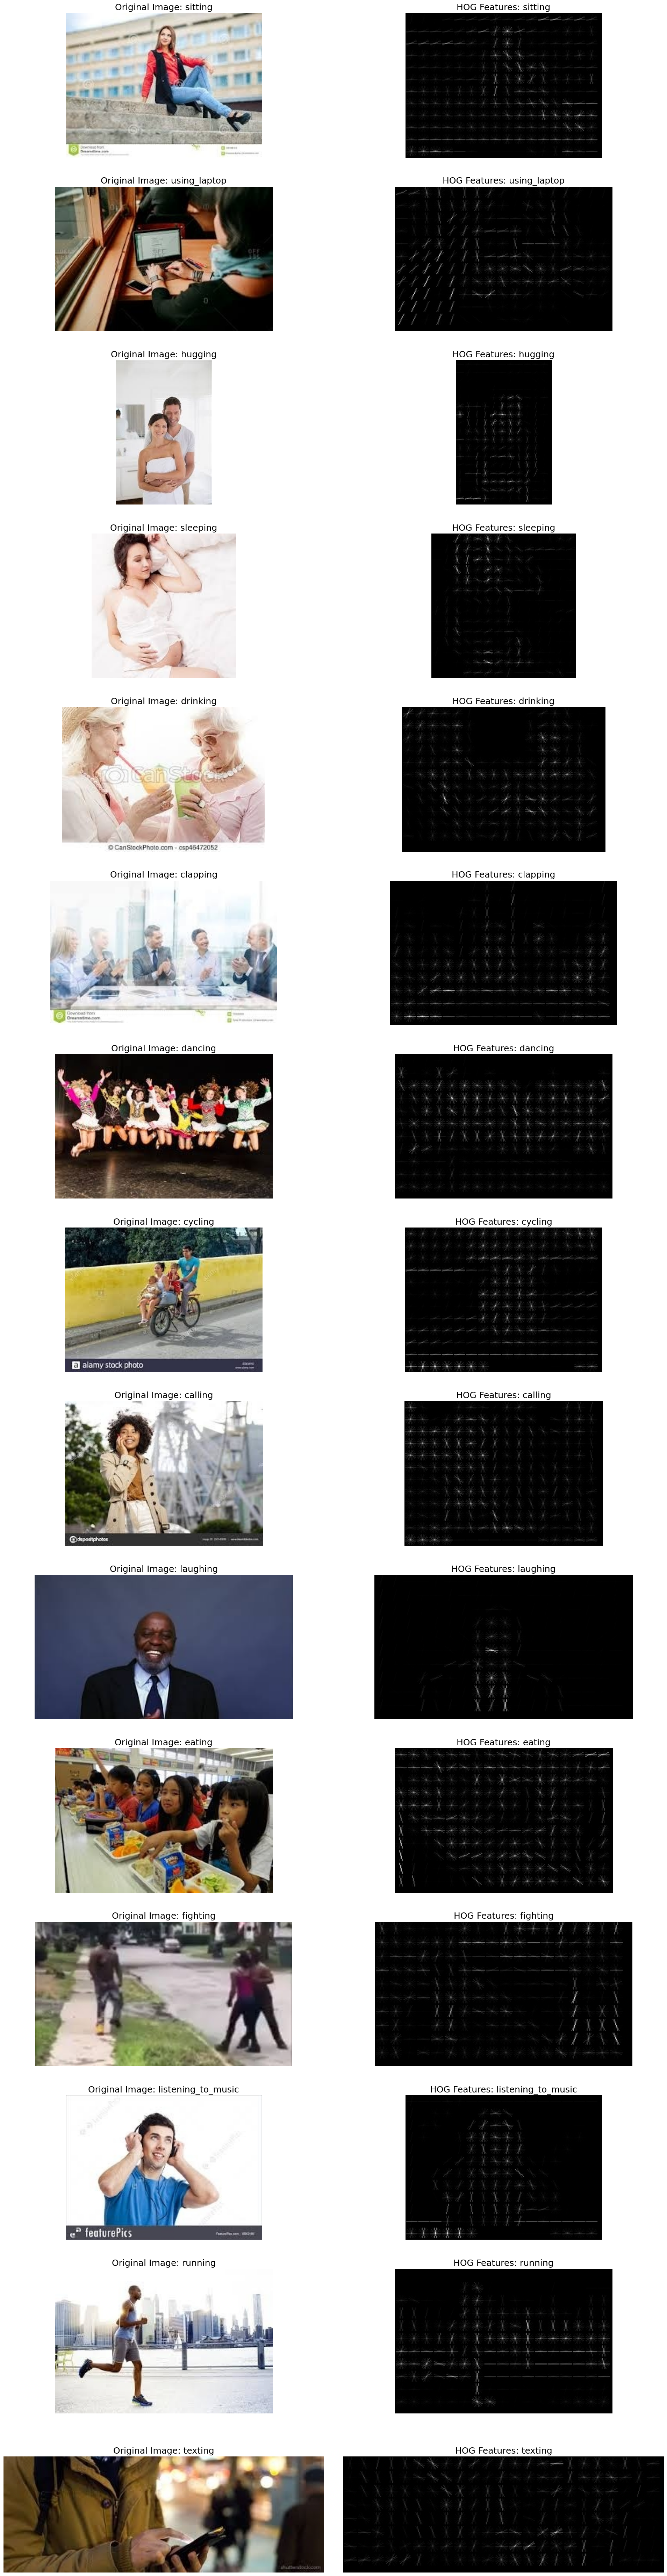

In [47]:
plt.figure(figsize=(20, len(classes) * 5))

for i, classLabel in enumerate(classes):
    rows = labelsCSV[labelsCSV['label'] == classLabel]
    sample = rows.sample(n = 1, random_state = 42)

    imgName = sample['filename'].values[0]
    imgPath = os.path.join(imagesFolderPath, imgName)

    img = cv2.imread(imgPath)

    grayImg = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    hogFeatures, hogImg = feature.hog(grayImg, pixels_per_cell = (16, 16), cells_per_block = (2, 2), block_norm = 'L2-Hys', visualize = True, feature_vector = True)

    plt.subplot(len(classes), 2, i * 2 + 1)
    plt.title("Original Image: " + str(classLabel), fontsize = 20 - 2)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(len(classes), 2, i * 2 + 2)
    plt.title("HOG Features: " + str(classLabel), fontsize = 20 - 2)
    plt.imshow(hogImg, cmap = 'gray')
    plt.axis('off')

plt.tight_layout(pad = 4.0)
plt.show()

In [48]:
def extractColorHistogram(image):
    hsvImage = cv2.cvtColor(image, cv2.COLOR_BGR2HSV) # hsv color space
    rgbImage = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # rgb color space

    bins = (8, 8, 8)  # divide range of color in smaller sections of 8, 8, 8 for color space
    hsvRanges = [0, 180, 0, 256, 0, 256]  # range of hsv values to be evaluated
    rgbRanges = [0, 256, 0, 256, 0, 256]  # range of rgb values to be evaluated
    # [0, 1, 2] ensures all 3 channels in hsv and rgb both are considered

    hsvHistogram = cv2.calcHist([hsvImage], [0, 1, 2], None, bins, hsvRanges)
    rgbHistogram = cv2.calcHist([rgbImage], [0, 1, 2], None, bins, rgbRanges)

    cv2.normalize(hsvHistogram, hsvHistogram)
    cv2.normalize(rgbHistogram, rgbHistogram)

    return np.concatenate((hsvHistogram.flatten(), rgbHistogram.flatten()))

In [49]:
def extractLBPfeatures(img):
    p = 8 # number of neighbors considered around each pixel
    r = 1 # distance from the center pixel to the neighbors
    lbp = feature.local_binary_pattern(img, p, r, method = 'uniform')


    lbpFlattened = lbp.ravel()   # flatten LBP array to 1D
    binEdges = np.arange(0, p + 3)   # histogram bins
    histogramRange = (0, p + 2)   # range for histogram
    histo, binEdges = np.histogram(lbpFlattened, binEdges, histogramRange)

    histo = histo.astype("float")
    histo /= histo.sum()  # normalisation

    return histo

In [58]:
X = []
Y = labelsCSV['label'].values

for index, row in labelsCSV.iterrows():
    imgPath = os.path.join(imagesFolderPath, row['filename'])
    img = cv2.imread(imgPath)

    sizeDimensions = (128, 128)   # ensures same size of all images -> same size of feature array for all images
    resizedImg = cv2.resize(img, sizeDimensions)
    grayImg = cv2.cvtColor(resizedImg, cv2.COLOR_BGR2GRAY)    # simplify feature extraction, one channel (black/white) instead of three (hsv/rgb)

    hogFeatures = extractHOGfeatures(grayImg)
    colorHistogramFeatures = extractColorHistogram(resizedImg)
    lbpFeatures = extractLBPfeatures(grayImg)

    # print("Processing Image No.", index)
    # print("HOG Feature Count:", len(hogFeatures))
    # print("Color Histogram Feature Count:", len(colorHistogramFeatures))
    # print("LBP Feature Count:", len(lbpFeatures))
    # print()
    featureArray = np.concatenate((hogFeatures, colorHistogramFeatures, lbpFeatures))
    X.append(featureArray)

print("Features have been extracted")
print("Total Number of Features per image:", len(X[0]))

Features have been extracted
Total Number of Features per image: 2798


In [51]:
X = np.array(X)

print("Size of X (features):", X.shape)
print("Size of y (labels):", len(Y))

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Size of X_train (scaled):", X_train.shape)
print("Size of X_test (scaled):", X_test.shape)

Size of X (features): (12600, 2798)
Size of y (labels): 12600
Size of X_train (scaled): (10080, 2798)
Size of X_test (scaled): (2520, 2798)


In [59]:
drivePath = '/content/drive/MyDrive/CSVs/'
fileName = 'X_array.npy'
filePath = os.path.join(drivePath, fileName)

if not os.path.exists(drivePath):
    os.makedirs(drivePath)

np.save(filePath, X)
print("X array saved at:", filePath)

if os.path.exists(filePath):
    X_load = np.load(filePath)
    print("Loaded X array in X_load")
else:
    print("File does not exist.")

X array saved at: /content/drive/MyDrive/CSVs/X_array.npy
Loaded X array in X_load


In [53]:
X = np.array(X_load)

print("Size of X (features):", X.shape)
print("Size of y (labels):", len(Y))

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Size of X_train (scaled):", X_train.shape)
print("Size of X_test (scaled):", X_test.shape)

Size of X (features): (12600, 2798)
Size of y (labels): 12600
Size of X_train (scaled): (10080, 2798)
Size of X_test (scaled): (2520, 2798)


# Part C

In [54]:
models = {'Naive Bayes': GaussianNB(), 'Decision Tree': DecisionTreeClassifier(random_state = 42), 'Perceptron': Perceptron(random_state = 42), 'Random Forest': RandomForestClassifier(random_state = 42)}

results = {}
count = 1

for modelName, model in models.items():
    print(str(count) + ". " + modelName)

    model.fit(X_train, Y_train)
    y_predictions = model.predict(X_test)
    accuracy = accuracy_score(Y_test, y_predictions)
    results[modelName] = accuracy

    print(modelName + " Accuracy: " + str(accuracy))
    count += 1

1. Naive Bayes
Naive Bayes Accuracy: 0.16785714285714284
2. Decision Tree
Decision Tree Accuracy: 0.18253968253968253
3. Perceptron
Perceptron Accuracy: 0.2563492063492063
4. Random Forest
Random Forest Accuracy: 0.32976190476190476


In [55]:
labelEncoder = LabelEncoder()

Y_trainEncoded = labelEncoder.fit_transform(Y_train)  # fit the encoder to Y_train and transform it into numerical labels
Y_testEncoded = labelEncoder.transform(Y_test)  # transform Y_test into numerical labels

# logloss is logistic loss used for classification
xgbModel = XGBClassifier(use_label_encoder = False, eval_metric = 'logloss', random_state = 42)
xgbModel.fit(X_train, Y_trainEncoded)

Y_predEncoded = xgbModel.predict(X_test)

# gets the original labels back
Y_predOriginal = labelEncoder.inverse_transform(Y_predEncoded)

accuracy = accuracy_score(Y_test, Y_predOriginal)
print("XGBoost Accuracy:", accuracy)

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [15:12:30] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Accuracy: 0.4087301587301587


In [60]:
votingClassifier = VotingClassifier(estimators = [('xgb', xgbModel), ('rf', models['Random Forest'])], voting = 'soft')
# soft voting aggregates class probabilities from multiple models
# hard voting predicts the class label based on majority voting

votingClassifier.fit(X_train, Y_trainEncoded)

Y_ensemblePredictions = votingClassifier.predict(X_test)

# gets the original labels back
Y_ensemblePredOriginal = labelEncoder.inverse_transform(Y_ensemblePredictions)

accuracy = accuracy_score(Y_test, Y_ensemblePredOriginal)
print("Ensemble Model Accuracy:", accuracy)

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [15:53:59] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Ensemble Model Accuracy: 0.4158730158730159


In [61]:
drivePath = '/content/drive/MyDrive/CSVs/'

vcFile = open(drivePath + 'votingClassifier.pkl', 'wb')
pickle.dump(votingClassifier, vcFile)
vcFile.close()

xgbFile = open(drivePath + 'xgboostModel.pkl', 'wb')
pickle.dump(xgbModel, xgbFile)
xgbFile.close()

rfFile = open(drivePath + 'randomForestModel.pkl', 'wb')
pickle.dump(models['Random Forest'], rfFile)
rfFile.close()

# saving label encoder to ensure reproducibility
leFile = open(drivePath + 'labelEncoder.pkl', 'wb')
pickle.dump(labelEncoder, leFile)
leFile.close()

print("Models and Label Encoder have been saved")

Models and Label Encoder have been saved


In [62]:
vcFile = open(drivePath + 'votingClassifier.pkl', 'rb')
vcLoaded = pickle.load(vcFile)
vcFile.close()

xgbFile = open(drivePath + 'xgboostModel.pkl', 'rb')
xgbModelLoaded = pickle.load(xgbFile)
xgbFile.close()

rfFile = open(drivePath + 'randomForestModel.pkl', 'rb')
rfModelLoaded = pickle.load(rfFile)
rfFile.close()

leFile = open(drivePath + 'labelEncoder.pkl', 'rb')
labelEncoderLoaded = pickle.load(leFile)
leFile.close()

print("Models and Label Encoder have been loaded")

Models and Label Encoder have been loaded


In [63]:
Y_rfPredictions = rfModelLoaded.predict(X_test)
Y_xgbPredictions = xgbModelLoaded.predict(X_test)
Y_vcPredictions = vcLoaded.predict(X_test)

Y_xgbPredOriginal = labelEncoderLoaded.inverse_transform(Y_xgbPredictions)
Y_vcPredOriginal = labelEncoderLoaded.inverse_transform(Y_vcPredictions)

rfAccuracy = accuracy_score(Y_test, Y_rfPredictions)
xgbAccuracy = accuracy_score(Y_test, Y_xgbPredOriginal)
vcAccuracy = accuracy_score(Y_test, Y_vcPredOriginal)

print("Random Forest Accuracy:", rfAccuracy)
print("XGBoost Accuracy:", xgbAccuracy)
print("Ensemble Model Accuracy:", vcAccuracy)

Random Forest Accuracy: 0.32976190476190476
XGBoost Accuracy: 0.4087301587301587
Ensemble Model Accuracy: 0.4158730158730159
